# Relation 2: Physics of complex systems

Diego Contreras Olmos

### Exercise 2: Fractal Dimension

In [3]:
### LIBRERÍAS #################

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
### FUNCIONES #################

#I will define a function that creates the carpet using a parameter of k iterations. So the only parameter it needs is this one, i will call it 'iter'

def generar_alfombra(iter):
    """It will generate the carpet dividing the matrix in 4x4 to the power of the number of iterations and removing the 4 in the middle.

    Args:
        iter (natural): the number of total iterations you want to do
    """
    
    
    matriz = np.array([[1]], dtype=int) #In iteration 0 we have a whole, a scalar.
    
    #Now we create the matrix divided.
    
    for _ in range(iter):   #This is to get a name of the new matrix
        fila, columna = matriz.shape
        nueva_matriz = np.zeros((fila*4, columna*4), dtype=int)
    
    #Now we assing a 1 if it is occupied and a 0 if it is removed.
    
        for i in range(fila):
            for j in range(columna):
                
                if matriz[i][j]==1:
                    #We separate in chunks, 'bloques':
                    bloque=np.ones((4,4), dtype=int)
                    
                    #We remove the 4 in the middle
                    bloque[1,1]=0
                    bloque[1,2]=0
                    bloque[2,1]=0
                    bloque[2,2]=0
                    
                    #Now we iterate the 'nueva_matriz' for all cases that this is fulfilled (we go from 4*i to 4*i+4)
                    
                    nueva_matriz[4*i:4*i+4, 4*j:4*j+4] = bloque
                    
        
                #Now we update the matriz and return it
        matriz=nueva_matriz
    
    return matriz





#Another function is to count all the boxes that we have. It is pretty self explanatory, I will count all not-null states.
#We need the matrix and the size of the box that you want to.

def contar(matriz, size):
    """Count all the boxes with number 1

    Args:
        matriz (matrix): The matrix you wish the components to be counted
        size (whole): The size of the box that you want to count
    """
    
    n=matriz.shape[0] #The matrix is nxn, so how many columns or rows does it have?
    contador = 0
    
    #We do all states of the matrix
    for i in range(0,n,size):
        for j in range(0,n,size):
            
            submatrix=matriz[i:i+size, j:j+size] #We divide the total matrix in blocks
            #If there is a 1 in the matrix, count it. The funciton np.any also has a loop inside
            if np.any(submatrix==1):
                contador=contador+1
    
    return contador


#Another funciton is to do the total dimension of the box. We only need the total matrix.

def dimension_caja(matriz):
    """Counts and calculates the fractal dimension of the system.

    Args:
        matriz (matrix): The matrix you wish to be counted and calculated.
    """
    
    n = matriz.shape[0]
    
    #Now we need a way to categorize the boxes inside and their size. Because I dont know their dimension, blank arrays and python will do the rest:
    #The arrays will contain the evolution of the count when we increase the size.
        
    sizes=[]
    count=[]
    
    #We want to start from the very little.
    
    size=1
    while size <=n:
        if n % size ==0:
            num_boxes = contar(matriz, size)
            sizes.append(size)
            count.append(num_boxes)
        size=size*4
    
    #For us to plot it nicely, we transform it to a numpy array.
    
    sizes=np.array(sizes, dtype=float)
    count=np.array(count, dtype=float)
    
    #Now the real calculation. We take the values we have calculated and obtain the relation. It should be a straight line so i will do a polyfit of degree 1 instead of a curve_fit. 
    
    x=np.log(1/sizes)
    y=np.log(count)
    coef=np.polyfit(x,y,1)
    dimension=coef[0]
    
    return dimension, sizes, count

    

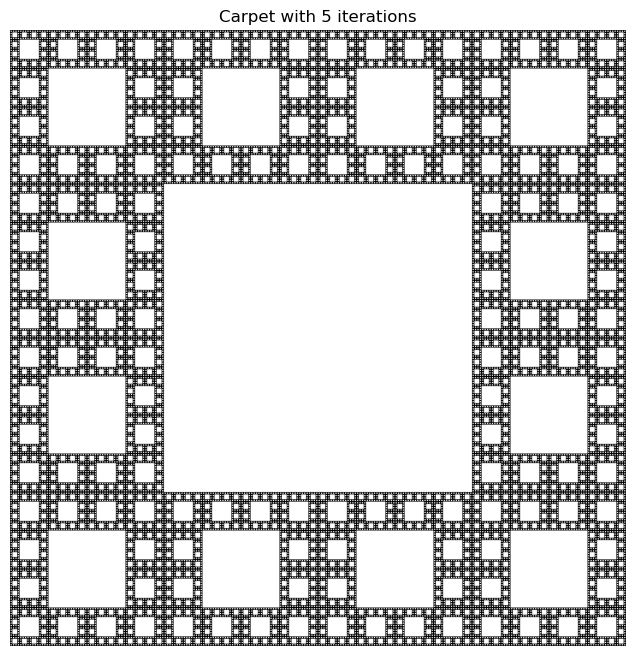

Sizes of the box: [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02 1.024e+03]
Number of occupied boxs:  [2.48832e+05 2.07360e+04 1.72800e+03 1.44000e+02 1.20000e+01 1.00000e+00]
Dimension of the box = 1.79248


In [18]:
### PLOT AND CALCULATION OF THE CARPET ################

#Assign a number of iterations
iteraciones=5

fractal = generar_alfombra(iteraciones)

#Now the plot

plt.figure(figsize=(8,8))
plt.imshow(fractal, cmap="binary")
plt.title(f"Carpet with {iteraciones} iterations")
plt.axis("off")
plt.show()

#Now to calculate the dimension

dimension, sizes, counts = dimension_caja(fractal)

print("Sizes of the box:", sizes)
print("Number of occupied boxs: ", counts)
print(f"Dimension of the box = {dimension:.5f}") #5 decimals should do

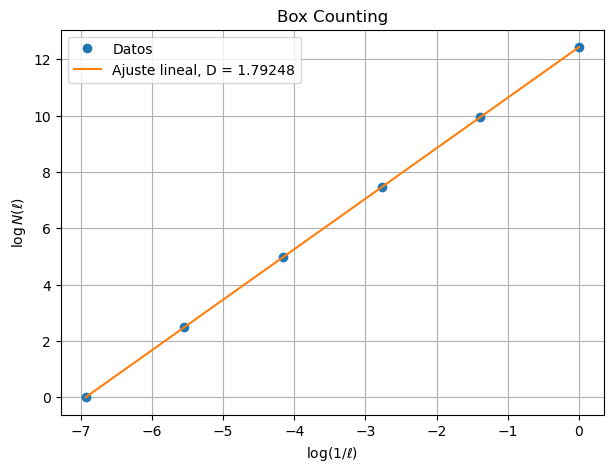

In [ ]:
### PLOT OF THE LINEAL FIT ##################

x = np.log(1 / sizes)
y = np.log(counts)

coef = np.polyfit(x, y, 1)
ajuste = coef[0] * x + coef[1]

plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Datos')
plt.plot(x, ajuste, '-', label=f'Ajuste lineal, D = {coef[0]:.5f}')
plt.xlabel(r'$\log(1/\ell)$')
plt.ylabel(r'$\log N(\ell)$')
plt.title('Box Counting')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 3: Enhrenfest Urn with a twist